<a href="https://colab.research.google.com/github/Fachreza28/pba-task-1a-individual/blob/main/WEEK_3_EDA_MyBCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WEEK 3 EDA for Google Apps Review
irma@its.ac.id/ PBA 2025

In [1]:
from google.colab import files
uploaded = files.upload()

Saving df_mybcarev_before_stopwords_sentiment_rating.csv to df_mybcarev_before_stopwords_sentiment_rating.csv


In [2]:
import pandas as pd

df_mybcarev = pd.read_csv('df_mybcarev_before_stopwords_sentiment_rating.csv')
df_mybcarev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount,sentiment_rating
0,dc58de2a-b0f2-4b4c-84d3-fcd64b24e0df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,4.7.9,2026-03-29 12:58:17,Thank you for the review. Hopefully the BCA mo...,2026-03-29 14:04:27,4.7.9,0.5,0.5,1,0,0,Positive
1,122b9d3b-f122-48b3-b1c0-54e54cf52923,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"susa amat buat qris di cek internet bagus, dic...",1,0,4.7.9,2026-03-29 12:30:18,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-03-29 12:48:54,4.7.9,0.0,0.0,21,0,3,Negative
2,d6bcfc0c-e9d0-4115-97f6-c110a9d5ba41,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ter indah tiasa 2 nya....,5,0,4.7.9,2026-03-29 12:05:14,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 12:48:28,4.7.9,0.0,0.0,5,0,4,Positive
3,d795e116-5f04-47d8-866c-5592036801d4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dengan bca mobile transaksi lebih mudah ga pak...,5,0,4.7.9,2026-03-29 11:39:58,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:44:30,4.7.9,0.0,0.0,26,0,0,Positive
4,a210fcc0-b3ed-4da5-bd31-287327b008bb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,5,0,4.7.9,2026-03-29 11:39:20,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:42:58,4.7.9,0.0,0.0,6,0,0,Positive


# Exploratory Data Analysis (EDA) of MyBCA Reviews

## 1. Install Necessary Packages
This section ensures that all required Python packages are installed before running the notebook.
```python
!pip install pandas matplotlib seaborn nltk
```

In [3]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries
We import essential libraries for data analysis, visualization, and text processing.
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
```

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

## 3. Download Stopwords
Downloading the Indonesian stopwords from NLTK for text processing.
```python
nltk.download('stopwords')
from nltk.corpus import stopwords
```

In [5]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
!pip install Sastrawi

import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


# Create stemmer and lemmatizer objects
factory = StemmerFactory()
stemmer = factory.create_stemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Case lowering
    text = text.lower()

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text)

    # Stemming saja (hapus lemmatization)
    text = stemmer.stem(text)

    return text

df_mybcarev_sample = df_mybcarev.head(500)  # coba 500 dulu

df_mybcarev_sample['cleaned_review'] = df_mybcarev_sample['content'].apply(clean_text)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
/tmp/ipykernel_2074/3685648255.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mybcarev_sample['cleaned_review'] = df_mybcarev_sample['content'].apply(clean_text)


## 5. Data Overview
This section provides basic dataset information, including column names, data types, and the first few records.
```python
# Convert 'at' column to datetime format
df_mybcarev['at'] = pd.to_datetime(df_mybcarev['at'])

# Display dataset info and first few rows
df_mybcarev.info()
df_mybcarev.head()
```

In [8]:
# Convert 'at' column to datetime format
df_mybcarev['at'] = pd.to_datetime(df_mybcarev['at'])

# Display dataset info and first few rows
df_mybcarev.info()
df_mybcarev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512156 entries, 0 to 512155
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              512156 non-null  object        
 1   userName              512156 non-null  object        
 2   userImage             512156 non-null  object        
 3   content               512032 non-null  object        
 4   score                 512156 non-null  int64         
 5   thumbsUpCount         512156 non-null  int64         
 6   reviewCreatedVersion  405729 non-null  object        
 7   at                    512156 non-null  datetime64[ns]
 8   replyContent          479277 non-null  object        
 9   repliedAt             479277 non-null  object        
 10  appVersion            405729 non-null  object        
 11  sentiment_polarity    512156 non-null  float64       
 12  sentiment_subjective  512156 non-null  float64       
 13 

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount,sentiment_rating
0,dc58de2a-b0f2-4b4c-84d3-fcd64b24e0df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,4.7.9,2026-03-29 12:58:17,Thank you for the review. Hopefully the BCA mo...,2026-03-29 14:04:27,4.7.9,0.5,0.5,1,0,0,Positive
1,122b9d3b-f122-48b3-b1c0-54e54cf52923,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"susa amat buat qris di cek internet bagus, dic...",1,0,4.7.9,2026-03-29 12:30:18,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-03-29 12:48:54,4.7.9,0.0,0.0,21,0,3,Negative
2,d6bcfc0c-e9d0-4115-97f6-c110a9d5ba41,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ter indah tiasa 2 nya....,5,0,4.7.9,2026-03-29 12:05:14,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 12:48:28,4.7.9,0.0,0.0,5,0,4,Positive
3,d795e116-5f04-47d8-866c-5592036801d4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dengan bca mobile transaksi lebih mudah ga pak...,5,0,4.7.9,2026-03-29 11:39:58,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:44:30,4.7.9,0.0,0.0,26,0,0,Positive
4,a210fcc0-b3ed-4da5-bd31-287327b008bb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,5,0,4.7.9,2026-03-29 11:39:20,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:42:58,4.7.9,0.0,0.0,6,0,0,Positive


## 6. Missing Values Analysis
Identifies and counts missing values in each column.
```python
missing_values = df_mybcarev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)
```

## 7. Review Score Distribution
Visualizing the distribution of review scores to understand user sentiments.
```python
plt.figure(figsize=(8,5))
sns.countplot(x=df_mybcarev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()
```

/tmp/ipykernel_2074/721435032.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_mybcarev['score'], palette="viridis")


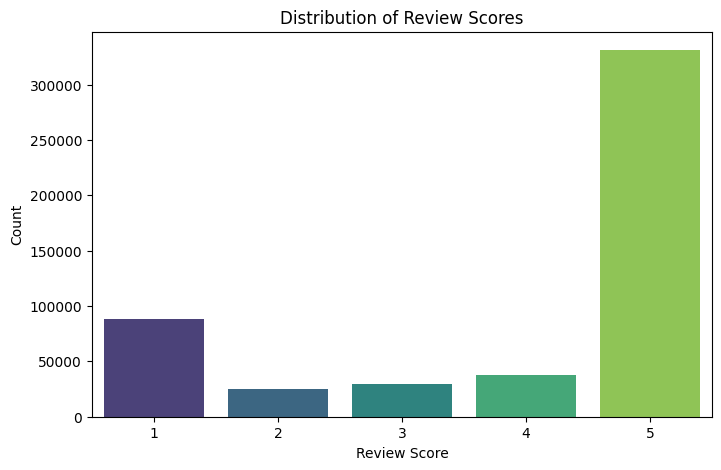

In [12]:
## 7. Review Score Distribution
##Visualizing the distribution of review scores to understand user sentiments.

plt.figure(figsize=(8,5))
sns.countplot(x=df_mybcarev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


## 8. Review Trends Over Time
Analyzing how the number of reviews changes over time to detect patterns.
```python
# Extract review date
df_mybcarev['review_date'] = df_mybcarev['at'].dt.date
review_trend = df_mybcarev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()
```

In [13]:
## 9. Word Frequency Analysis
##Analyzing common words in reviews, excluding Indonesian stopwords.

stop_words = set(stopwords.words('indonesian'))

# Combine all review text
all_reviews = " ".join(df_mybcarev['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)



Most Common Words in Reviews:
         Word  Frequency
0         bca      82536
1    membantu      46931
2       bagus      44424
3         nya      38310
4          ok      34774
5    aplikasi      31901
6   transaksi      29896
7        good      29555
8      update      29297
9          ga      28918
10        gak      27130
11         yg      25239
12     mobile      24742
13     mantap      23779
14      mudah      22991
15         ya      22887
16      masuk      18618
17        aja      17180
18      saldo      16898
19     tolong      16703
